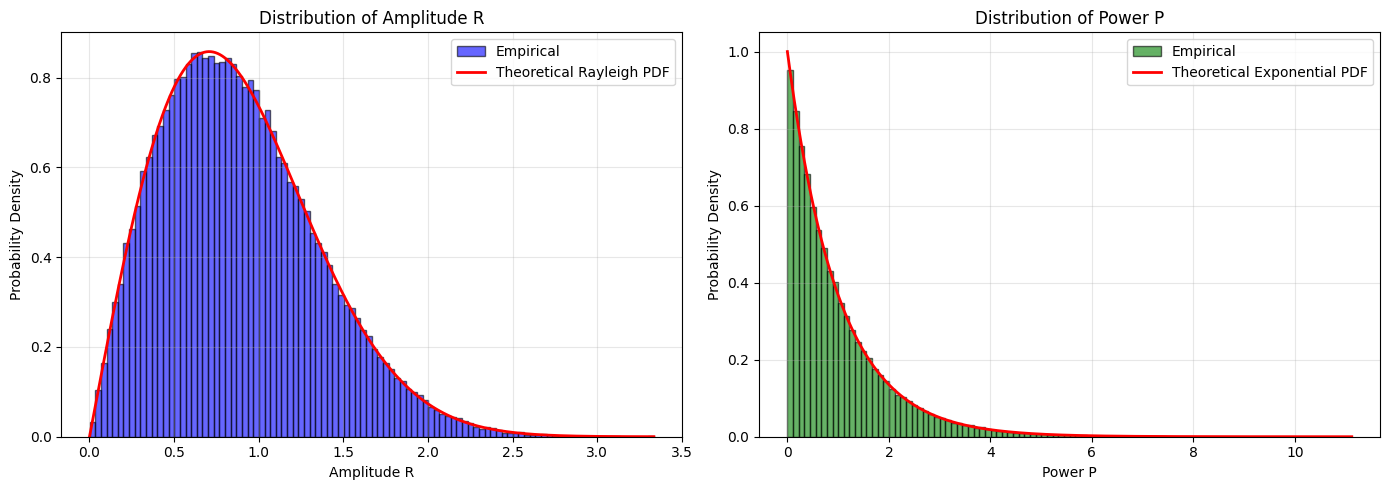

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
sigma = 1.0/(math.sqrt(2)) # Standard deviation
n_samples = 100000  # 10^5 samples

# Generate independent Gaussian random variables X and Y
X = np.random.normal(0, sigma, n_samples)
Y = np.random.normal(0, sigma, n_samples)

# Compute amplitude R and power P
R = np.sqrt(X**2 + Y**2)
P = R**2

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of R with Rayleigh PDF overlay
ax1.hist(R, bins=100, density=True, alpha=0.6, color='blue', 
         edgecolor='black', label='Empirical')

# Theoretical Rayleigh PDF
r_values = np.linspace(0, np.max(R), 1000)
rayleigh_pdf = (r_values / sigma**2) * np.exp(-r_values**2 / (2 * sigma**2))
ax1.plot(r_values, rayleigh_pdf, 'r-', linewidth=2, 
         label='Theoretical Rayleigh PDF')

ax1.set_xlabel('Amplitude R')
ax1.set_ylabel('Probability Density')
ax1.set_title('Distribution of Amplitude R')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Histogram of P with Exponential PDF overlay
ax2.hist(P, bins=100, density=True, alpha=0.6, color='green', 
         edgecolor='black', label='Empirical')

# Theoretical Exponential PDF
p_values = np.linspace(0, np.max(P), 1000)
lambda_param = 1 / (2 * sigma**2)
exponential_pdf = lambda_param * np.exp(-lambda_param * p_values)
ax2.plot(p_values, exponential_pdf, 'r-', linewidth=2, 
         label='Theoretical Exponential PDF')

ax2.set_xlabel('Power P')
ax2.set_ylabel('Probability Density')
ax2.set_title('Distribution of Power P')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


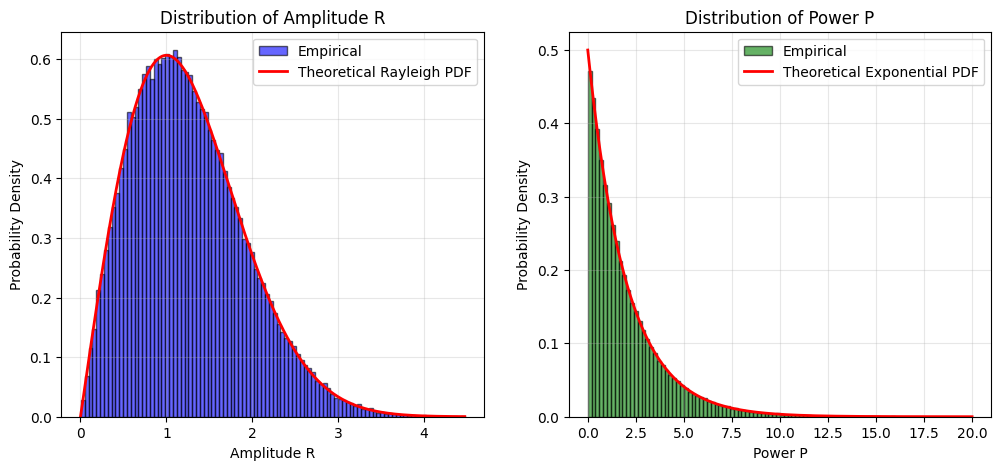

In [2]:
n_samples = 1e5
sigma = 1.0
x=np.random.normal(0, sigma, int(n_samples))
y=np.random.normal(0, sigma, int(n_samples))
R=np.sqrt(x**2+y**2)
P=R**2
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(R, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black', label='Empirical')
r=np.linspace(0, np.max(R), 1000)
rayleigh_pdf = (r / (sigma**2)) * np.exp(-r**2 / (2 * (sigma**2)))
plt.plot(r, rayleigh_pdf, 'r-', linewidth=2, label='Theoretical Rayleigh PDF')
plt.xlabel('Amplitude R')
plt.ylabel('Probability Density')
plt.title('Distribution of Amplitude R')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.hist(P, bins=100, density=True, alpha=0.6, color='green', edgecolor='black', label='Empirical')
p=np.linspace(0, np.max(P), 1000)
exponential_pdf = (1/(2*sigma**2)) * np.exp(- (p / (2 * (sigma**2))))
plt.plot(p, exponential_pdf, 'r-', linewidth=2, label='Theoretical Exponential PDF')
plt.xlabel('Power P')
plt.ylabel('Probability Density')
plt.title('Distribution of Power P')
plt.legend()
plt.grid(True, alpha=0.3)

In [3]:
pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.


Avg |error| - Mean  : 0.3676
Avg |error| - Median: 0.1370
Median is 2.68x more accurate than Mean


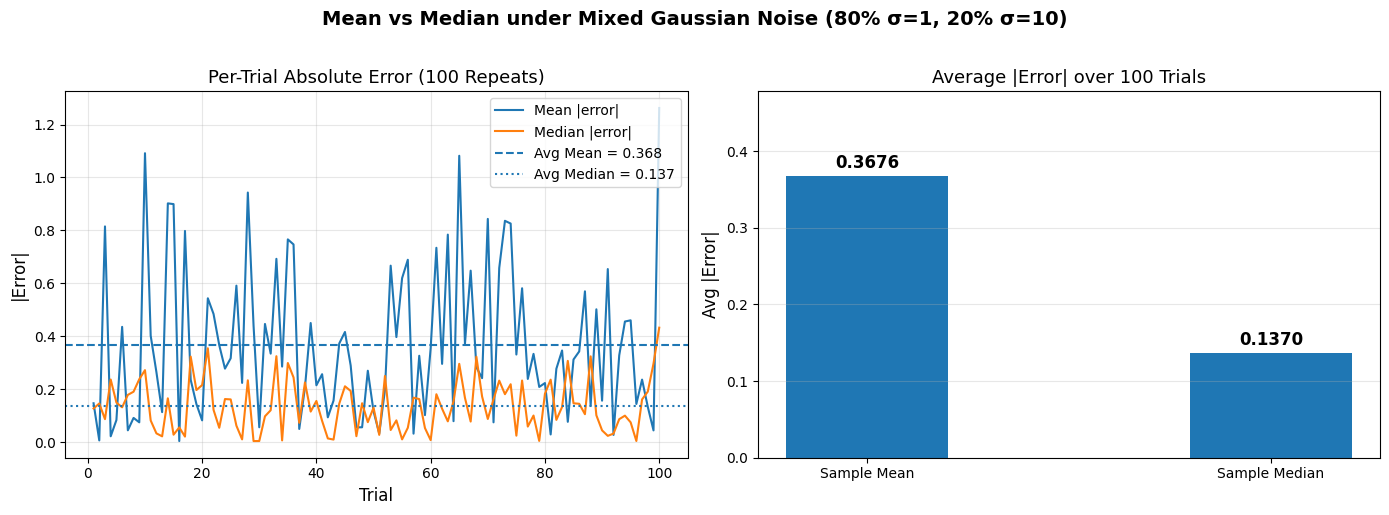

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Parameters ───────────────────────────────────────────────
true_x    = 0.0
N         = 100
n_trials  = 100
n_clean   = 80    # 80% Gaussian N(0,1)
n_outlier = 20    # 20% outlier  N(0,100) [sigma=10]

# ── Monte Carlo loop ─────────────────────────────────────────
mean_errors   = []
median_errors = []

for _ in range(n_trials):
    noise = np.concatenate([
        np.random.normal(0, 1,  n_clean),
        np.random.normal(0, 10, n_outlier)   # sigma=10 → variance=100
    ])
    np.random.shuffle(noise)
    z = true_x + noise

    x_mean   = np.mean(z)
    x_median = np.median(z)

    mean_errors.append(abs(x_mean   - true_x))
    median_errors.append(abs(x_median - true_x))

avg_mean_error   = np.mean(mean_errors)
avg_median_error = np.mean(median_errors)

print(f"Avg |error| - Mean  : {avg_mean_error:.4f}")
print(f"Avg |error| - Median: {avg_median_error:.4f}")
print(f"Median is {avg_mean_error / avg_median_error:.2f}x more accurate than Mean")

# ── Plot 1: Per-trial absolute error ─────────────────────────
trials = list(range(1, n_trials + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(trials, mean_errors,   linewidth=1.5, label="Mean |error|")
ax1.plot(trials, median_errors, linewidth=1.5, label="Median |error|")
ax1.axhline(avg_mean_error,   linestyle="--", linewidth=1.5,
            label=f"Avg Mean = {avg_mean_error:.3f}")
ax1.axhline(avg_median_error, linestyle=":",  linewidth=1.5,
            label=f"Avg Median = {avg_median_error:.3f}")
ax1.set_xlabel("Trial", fontsize=12)
ax1.set_ylabel("|Error|", fontsize=12)
ax1.set_title("Per-Trial Absolute Error (100 Repeats)", fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Bar chart of average errors ──────────────────────
ax2 = axes[1]
estimators = ["Sample Mean", "Sample Median"]
avg_errors = [avg_mean_error, avg_median_error]
bars = ax2.bar(estimators, avg_errors, width=0.4)

# Annotate bar values
for bar, val in zip(bars, avg_errors):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax2.set_ylabel("Avg |Error|", fontsize=12)
ax2.set_title("Average |Error| over 100 Trials", fontsize=13)
ax2.set_ylim(0, max(avg_errors) * 1.3)
ax2.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Mean vs Median under Mixed Gaussian Noise (80% σ=1, 20% σ=10)",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("estimator_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt

class SensorArray:
    def __init__(self,sensor_positions,sigma):
        self.sensor_positions = np.array(sensor_positions,dtype=np.float64)
        self.sigma = sigma
        self.R=(sigma**2)*np.eye(len(sensor_positions))
    
    def true_ranges(self,target):
        dx=self.sensor_positions-target
        return np.linalg.norm(dx,axis=1)
    
    def measure(self,target):
        noise=np.random.normal(0,self.sigma,size=len(self.sensor_positions))
        return self.true_ranges(target)+noise
    
class RangeModel:
    
    @staticmethod
    def h(x,sensor_positions):
        dx=sensor_positions-x
        return np.linalg.norm(dx,axis=1)
    
    @staticmethod
    def H(x,sensor_positions):
        dx=x-sensor_positions
        r=np.linalg.norm(dx,axis=1)
        r_=np.where(r==0,1e-6,r)
        return dx/r_[:,None]
    

class IteratedLS:
    def __init__(self,sensor_array,model,x0,maxiter=100,tol=1e-6):
        self.sensor_array=sensor_array
        self.model=model
        self.x_hat=x0.astype(np.float64).copy()
        self.maxiter=maxiter
        self.tol=tol
        self.history=[self.x_hat.copy()]
        
    def step(self,z):
        sp=self.sensor_array.sensor_positions
        H=self.model.H(self.x_hat,sp)
        h_xj=self.model.h(self.x_hat,sp)
        R_inv=np.linalg.inv(self.sensor_array.R)
        dz=z-h_xj
        A=H.T @ R_inv @ H
        b=H.T @ R_inv @ dz
        delta_x=np.linalg.solve(A,b)
        self.x_hat+=delta_x
        return delta_x
    
    def estimate(self,z):
        converged=False
        for _ in range(1,self.maxiter+1):
            delta_x=self.step(z)
            self.history.append(self.x_hat.copy())
            if np.linalg.norm(delta_x)<self.tol:
                converged=True
                break
        H_final=self.model.H(self.x_hat,self.sensor_array.sensor_positions)
        R_inv=np.linalg.inv(self.sensor_array.R)
        P=np.linalg.inv(H_final.T @ R_inv @ H_final)
        
        return {"x_hat":self.x_hat,"P":P,"converged":converged,"iterations":len(self.history)-1,"history":np.array(self.history)}

if __name__ =="__main__":
    np.random.seed(42)
    sensor_pos=SensorArray(sensor_positions=[(0,0),(10,0),(5,10)],sigma=0.5)
    model=RangeModel()
    true_target=np.array([6.0,4.0])
    z=sensor_pos.measure(true_target)
    x0=np.array([0.0,0.0])
    estimator=IteratedLS(sensor_array=sensor_pos,model=model,x0=x0,maxiter=5,tol=1e-6)
    result=estimator.estimate(z)
    print(f"Estimated Position: {result['x_hat']}")
    print(f"True Position: {true_target}")
    print(f"Covariance Matrix:\n{result['P']}")
    
        

Estimated Position: [6.24281075 3.89923731]
True Position: [6. 4.]
Covariance Matrix:
[[0.20724862 0.02897174]
 [0.02897174 0.14614888]]


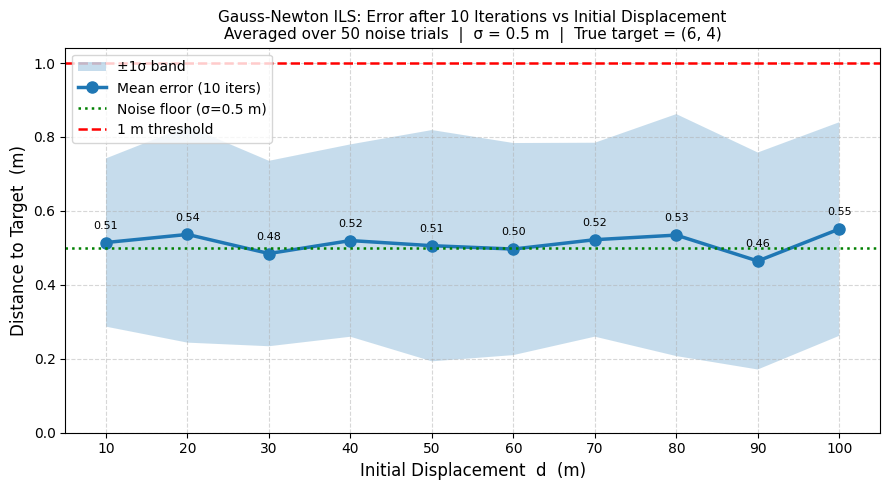

In [6]:
sensor_pos=SensorArray(sensor_positions=[(0,0),(10,0),(5,10)],sigma=0.5)
true_target=np.array([6.0,4.0])
disp=np.arange(10,110,10)
mean_errors,std_errors=[],[]
model=RangeModel()
SIGMA=0.5
N_TRIALS=50
for d in disp:
    x0=np.array([6.0+d,4.0])
    errors=[]
    for _ in range(N_TRIALS):
        z=sensor_pos.measure(true_target)
        estimator=IteratedLS(sensor_array=sensor_pos,model=model,x0=x0,maxiter=10,tol=1e-6)
        x_hat=estimator.estimate(z)["x_hat"]
        err=np.linalg.norm(x_hat-true_target) if np.all(np.isfinite(x_hat)) else np.nan
        errors.append(err)
    mean_errors.append(np.nanmean(errors))
    std_errors.append(np.nanstd(errors))

mean_errors=np.array(mean_errors)
std_errors=np.array(std_errors)
    

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(disp,
                mean_errors - std_errors,
                mean_errors + std_errors,
                alpha=0.25, label='±1σ band')

ax.plot(disp, mean_errors,
        marker='o', linewidth=2.5, markersize=8, label='Mean error (10 iters)')

ax.axhline(y=SIGMA, color='green', linestyle=':', linewidth=1.8,
           label=f'Noise floor (σ={SIGMA} m)')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.8,
           label='1 m threshold')

for d, me in zip(disp, mean_errors):
    ax.annotate(f'{me:.2f}', xy=(d, me), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=8)

ax.set_xlabel('Initial Displacement  d  (m)', fontsize=12)
ax.set_ylabel('Distance to Target  (m)', fontsize=12)
ax.set_title('Gauss-Newton ILS: Error after 10 Iterations vs Initial Displacement\n'
             f'Averaged over {N_TRIALS} noise trials  |  σ = {SIGMA} m  |  True target = (6, 4)',
             fontsize=11)
ax.set_xticks(disp)
ax.set_xlim(5, 105)
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ils_divergence.png', dpi=150)
plt.show()
    

Breaking point (conv < 50%): None — never breaks

    d | Mean Error (m) |  Std (m) |  Conv Rate
----------------------------------------------
   10 |         0.5122 |   0.2601 |     100.0%
   20 |         0.5170 |   0.2978 |      99.5%
   30 |         0.5185 |   0.2857 |     100.0%
   40 |         0.5124 |   0.2889 |      99.5%
   50 |         0.5288 |   0.2977 |      99.5%
   60 |         0.5827 |   0.2853 |     100.0%
   70 |         0.5240 |   0.2702 |     100.0%
   80 |         0.5243 |   0.2628 |     100.0%
   90 |         0.5258 |   0.2898 |      99.5%
  100 |         0.5574 |   0.2995 |      99.5%


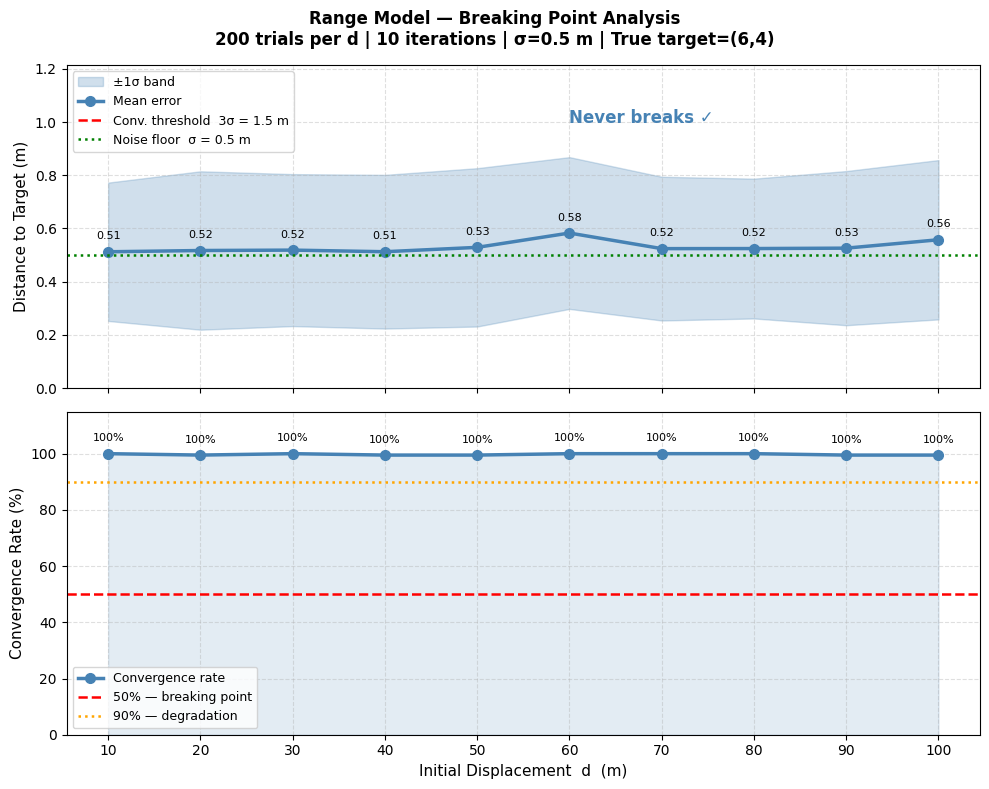

In [7]:
np.random.seed(42)
TRUE_TARGET = np.array([6.0, 4.0])
SIGMA       = 0.5
N_TRIALS    = 200
MAXITER     = 10
CONV_THRESH = 3 * SIGMA   # 1.5 m

sensors = SensorArray([(0, 0), (10, 0), (5, 10)], sigma=SIGMA)
model   = RangeModel()

displacements = list(range(10, 110, 10))   # d = 10, 20, ..., 100
mean_errors, std_errors, conv_rates = [], [], []

for d in displacements:
    x0     = np.array([6.0 + d, 4.0])
    errors = []
    for _ in range(N_TRIALS):
        z     = sensors.measure(TRUE_TARGET)
        est   = IteratedLS(sensors, model, x0=x0.copy(), maxiter=MAXITER)
        x_hat = est.estimate(z)['x_hat']
        err   = np.linalg.norm(x_hat - TRUE_TARGET) \
                if np.all(np.isfinite(x_hat)) else 999.0
        errors.append(err)
    errors = np.array(errors)
    mean_errors.append(np.nanmean(errors))
    std_errors.append(np.nanstd(errors))
    conv_rates.append(np.mean(errors < CONV_THRESH))

mean_errors = np.array(mean_errors)
std_errors  = np.array(std_errors)
conv_rates  = np.array(conv_rates)

# Breaking point
bp_idx = np.argmax(conv_rates < 0.5)
bp     = displacements[bp_idx] if conv_rates[bp_idx] < 0.5 else None
print(f"Breaking point (conv < 50%): {bp if bp else 'None — never breaks'}")
print(f"\n{'d':>5} | {'Mean Error (m)':>14} | {'Std (m)':>8} | {'Conv Rate':>10}")
print("-" * 46)
for d, me, se, cr in zip(displacements, mean_errors, std_errors, conv_rates):
    print(f"{d:>5} | {me:>14.4f} | {se:>8.4f} | {cr*100:>9.1f}%")

# ─────────────────────────────────────────────
#  Plot
# ─────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Range Model — Breaking Point Analysis\n'
             f'200 trials per d | 10 iterations | σ={SIGMA} m | True target=(6,4)',
             fontsize=12, fontweight='bold')

# ── Top: Mean Error ──
ax1.fill_between(displacements,
                 mean_errors - std_errors,
                 mean_errors + std_errors,
                 alpha=0.25, color='steelblue', label='±1σ band')
ax1.plot(displacements, mean_errors,
         color='steelblue', linewidth=2.5, marker='o', markersize=7,
         label='Mean error')
ax1.axhline(CONV_THRESH, color='red',   linestyle='--', linewidth=1.8,
            label=f'Conv. threshold  3σ = {CONV_THRESH} m')
ax1.axhline(SIGMA,       color='green', linestyle=':',  linewidth=1.8,
            label=f'Noise floor  σ = {SIGMA} m')
if bp:
    ax1.axvline(bp, color='orange', linestyle='-', linewidth=2.5,
                label=f'Breaking point  d = {bp} m')
else:
    ax1.text(0.55, 0.82, 'Never breaks ✓', transform=ax1.transAxes,
             fontsize=12, color='steelblue', fontweight='bold')
# Annotate values
for d, me in zip(displacements, mean_errors):
    ax1.annotate(f'{me:.2f}', xy=(d, me), xytext=(0, 9),
                 textcoords='offset points', ha='center', fontsize=8)
ax1.set_ylabel('Distance to Target (m)', fontsize=11)
ax1.set_ylim(0, max(mean_errors + std_errors) * 1.4)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.4)

# ── Bottom: Convergence Rate ──
ax2.plot(displacements, conv_rates * 100,
         color='steelblue', linewidth=2.5, marker='o', markersize=7,
         label='Convergence rate')
ax2.fill_between(displacements, conv_rates * 100, 0,
                 alpha=0.15, color='steelblue')
ax2.axhline(50, color='red',    linestyle='--', linewidth=1.8, label='50% — breaking point')
ax2.axhline(90, color='orange', linestyle=':',  linewidth=1.8, label='90% — degradation')
if bp:
    ax2.axvline(bp, color='orange', linestyle='-', linewidth=2.5,
                label=f'Breaking point  d = {bp} m')
# Annotate values
for d, cr in zip(displacements, conv_rates):
    ax2.annotate(f'{cr*100:.0f}%', xy=(d, cr*100), xytext=(0, 9),
                 textcoords='offset points', ha='center', fontsize=8)
ax2.set_xlabel('Initial Displacement  d  (m)', fontsize=11)
ax2.set_ylabel('Convergence Rate (%)', fontsize=11)
ax2.set_xticks(displacements)
ax2.set_ylim(0, 115)
ax2.legend(fontsize=9, loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('ils_range_breaking_point.png', dpi=150)
plt.show()